In [1]:
from pid_functions import *
import matplotlib.pyplot as plt
import time
import numpy as np

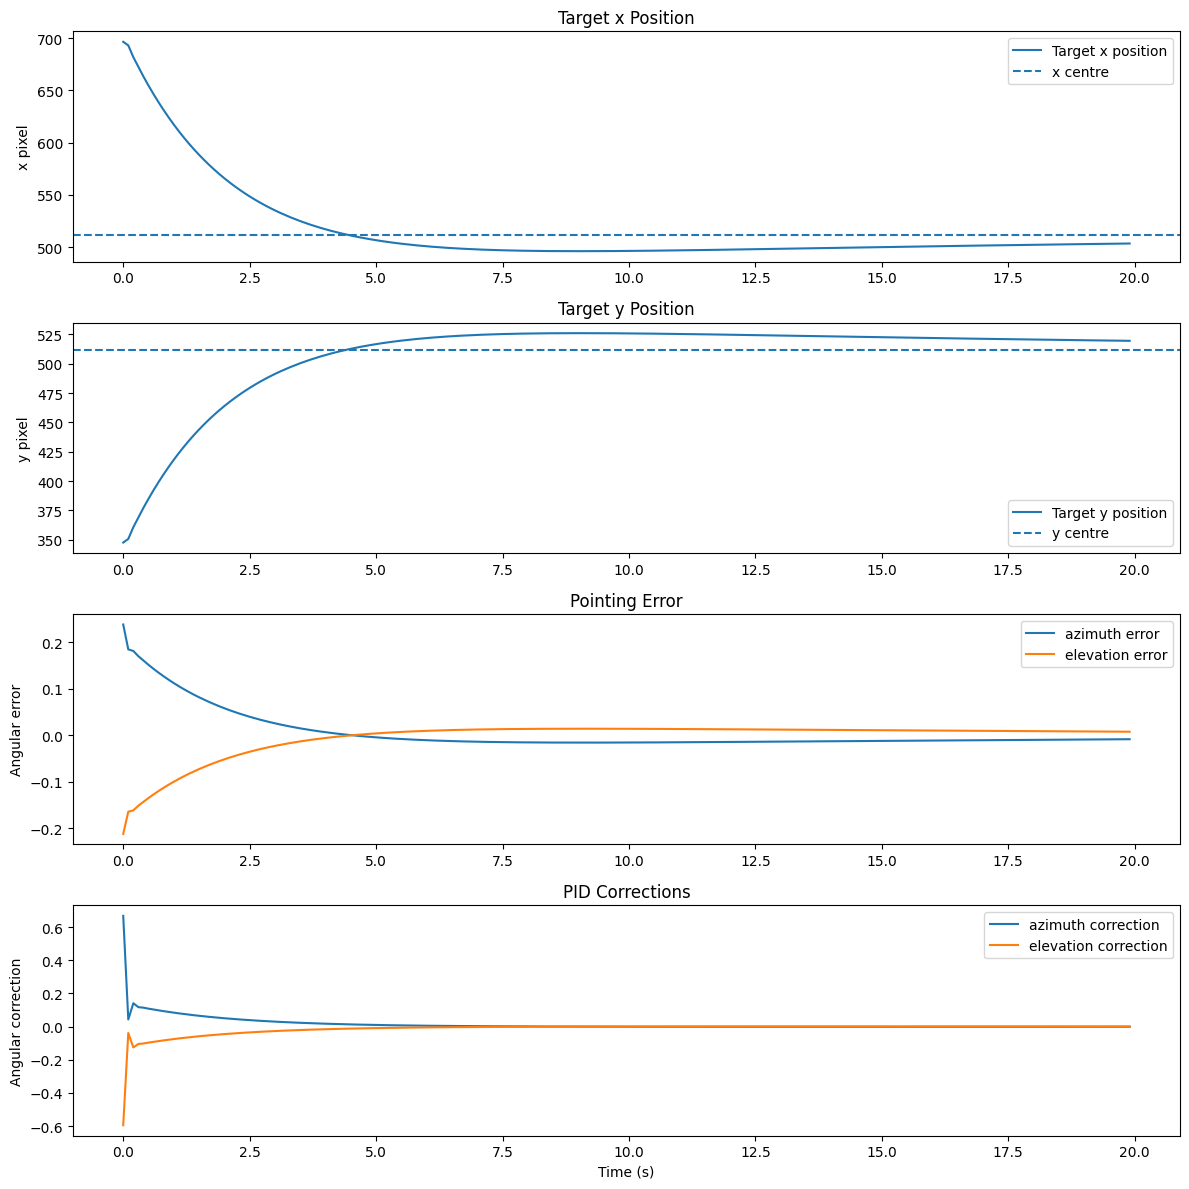

In [2]:
def main():

    # simulation settings
    dt = 0.1
    simulation_time = 20
    steps = int(simulation_time / dt)

    # camera
    x_centre = 512
    y_centre = 512

    x = 750
    y = 300


    plate_scale = 0.001
    camera_rotation = 0.0


    current_az = 135.0
    current_el = 45.0


    az_pid = PIDController(kp=0.8, ki=0.05, kd=0.2) 
    el_pid = PIDController(kp=0.8, ki=0.05, kd=0.2)


    time_values = []

    x_values = []
    y_values = []

    az_values = []
    el_values = []

    az_error_values = []
    el_error_values = []

    az_correction_values = []
    el_correction_values = []


    # begin simulation loop
    for i in range(steps):
        current_time = i * dt

        (
            new_az,
            new_el,
            error_az,
            error_el,
            az_correction,
            el_correction
        ) = pid_pointing_update(
            x=x,
            y=y,
            x_centre=x_centre,
            y_centre=y_centre,
            current_az=current_az,
            current_el=current_el,
            plate_scale=plate_scale,
            az_pid=az_pid,
            el_pid=el_pid,
            dt=dt,
            camera_rotation=camera_rotation
        )

        current_az = new_az
        current_el = new_el


        response_strength = 0.8

        x -= response_strength * (az_correction / plate_scale) * dt
        y -= response_strength * (el_correction / plate_scale) * dt

      
        time_values.append(current_time)

        x_values.append(x)
        y_values.append(y)

        az_values.append(current_az)
        el_values.append(current_el)

        az_error_values.append(error_az)
        el_error_values.append(error_el)

        az_correction_values.append(az_correction)
        el_correction_values.append(el_correction)

        time.sleep(dt)

    # -----------------------------
    # PLOT GRAPHS

    plt.figure(figsize=(12, 12))

    plt.subplot(4, 1, 1)
    plt.plot(time_values, x_values, label="Target x position")
    plt.axhline(x_centre, linestyle="--", label="x centre")
    plt.ylabel("x pixel")
    plt.title("Target x Position")
    plt.legend()

    plt.subplot(4, 1, 2)
    plt.plot(time_values, y_values, label="Target y position")
    plt.axhline(y_centre, linestyle="--", label="y centre")
    plt.ylabel("y pixel")
    plt.title("Target y Position")
    plt.legend()

    plt.subplot(4, 1, 3)
    plt.plot(time_values, az_error_values, label="azimuth error")
    plt.plot(time_values, el_error_values, label="elevation error")
    plt.ylabel("Angular error")
    plt.title("Pointing Error")
    plt.legend()

    plt.subplot(4, 1, 4)
    plt.plot(time_values, az_correction_values, label="azimuth correction")
    plt.plot(time_values, el_correction_values, label="elevation correction")
    plt.xlabel("Time (s)")
    plt.ylabel("Angular correction")
    plt.title("PID Corrections")
    plt.legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()